# Analysis of modeling result (prelim)

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

import rasterio
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.mask import mask

## Load all results

In [13]:
RESULTS_DIR = Path("../model/results/impact-assessment/batch03")
PATHS_DIR   = Path("../model/results/least-cost-paths")
DATA_DIR    = Path("../data")

list_of_csv = sorted(RESULTS_DIR.glob("assessment_*.csv"))
list_of_tif = sorted(RESULTS_DIR.glob("classified_*.tif"))

print(f"Found {len(list_of_csv)} CSV result files:")
for f in list_of_csv:
    print(f"  {f.name}")
print(f"\nFound {len(list_of_tif)} classified raster files:")
for f in list_of_tif:
    print(f"  {f.name}")

Found 4 CSV result files:
  assessment_late_and_early_stage__kribi__base__no_mask__ds1.csv
  assessment_late_and_early_stage__kribi__base__protected_areas__ds1.csv
  assessment_late_stage__kribi__base__no_mask__ds1.csv
  assessment_late_stage__kribi__base__protected_areas__ds1.csv

Found 4 classified raster files:
  classified_late_and_early_stage__kribi__base__no_mask__ds1.tif
  classified_late_and_early_stage__kribi__base__protected_areas__ds1.tif
  classified_late_stage__kribi__base__no_mask__ds1.tif
  classified_late_stage__kribi__base__protected_areas__ds1.tif


In [14]:
# Load and concatenate all scenario CSVs
df_raw = pd.concat([pd.read_csv(f) for f in list_of_csv], ignore_index=True)

# Parse scenario metadata from the scenario name
def parse_scenario(s):
    parts = s.split("__")
    stage = "Late + Early Stage" if parts[0] == "late_and_early_stage" else "Late Stage Only"
    mask_type = "Protected Areas" if "protected_areas" in s else "No Mask"
    return stage, mask_type

df_raw[["mining_stage", "mask_type"]] = pd.DataFrame(
    df_raw["scenario"].apply(parse_scenario).tolist(), index=df_raw.index
)

# Short label for plots
df_raw["label"] = df_raw["mining_stage"].str.replace(" + ", "+", regex=False) + "\n(" + df_raw["mask_type"] + ")"

df_raw

,scenario,paved_km,unpaved_km,to_be_built_km,total_km,mining_stage,mask_type,label
0,late_and_early_stage__kribi__base__no_mask__ds1,3865.33,255.72,79.77,4200.82,Late + Early Stage,No Mask,Late+Early Stage\n(No Mask)
1,late_and_early_stage__kribi__base__protected_a...,4035.37,278.84,96.09,4410.30,Late + Early Stage,Protected Areas,Late+Early Stage\n(Protected Areas)
2,late_stage__kribi__base__no_mask__ds1,2766.03,166.11,31.07,2963.21,Late Stage Only,No Mask,Late Stage Only\n(No Mask)
3,late_stage__kribi__base__protected_areas__ds1,2742.75,189.23,46.98,2978.95,Late Stage Only,Protected Areas,Late Stage Only\n(Protected Areas)


## Road classification metrics

Each mine-to-port path is classified into three categories:
- **Paved** — path follows an existing paved road (maintenance only)
- **Unpaved** — path follows an existing unpaved road (upgrade needed)
- **To be built** — no existing road; new construction required

In [15]:
# Summary table
summary = df_raw[[
    "mining_stage", "mask_type",
    "paved_km", "unpaved_km", "to_be_built_km", "total_km"
]].copy()

summary["paved_%"]       = (summary["paved_km"]       / summary["total_km"] * 100).round(1)
summary["unpaved_%"]     = (summary["unpaved_km"]     / summary["total_km"] * 100).round(1)
summary["to_be_built_%"] = (summary["to_be_built_km"] / summary["total_km"] * 100).round(1)

display_cols = [
    "mining_stage", "mask_type",
    "total_km",
    "paved_km", "paved_%",
    "unpaved_km", "unpaved_%",
    "to_be_built_km", "to_be_built_%"
]
summary[display_cols].style \
    .set_caption("Road classification metrics by scenario") \
    .format({
        "total_km": "{:.1f}", "paved_km": "{:.1f}",
        "unpaved_km": "{:.1f}", "to_be_built_km": "{:.1f}",
        "paved_%": "{:.1f}%", "unpaved_%": "{:.1f}%", "to_be_built_%": "{:.1f}%"
    }) \
    .set_table_styles([{"selector": "th", "props": [("font-size", "11px")]}]) \
    .highlight_max(subset=["to_be_built_km"], color="#ffd9cc") \
    .highlight_min(subset=["to_be_built_km"], color="#d4edda")

,mining_stage,mask_type,total_km,paved_km,paved_%,unpaved_km,unpaved_%,to_be_built_km,to_be_built_%
0,Late + Early Stage,No Mask,4200.8,3865.3,92.0%,255.7,6.1%,79.8,1.9%
1,Late + Early Stage,Protected Areas,4410.3,4035.4,91.5%,278.8,6.3%,96.1,2.2%
2,Late Stage Only,No Mask,2963.2,2766.0,93.3%,166.1,5.6%,31.1,1.0%
3,Late Stage Only,Protected Areas,2978.9,2742.8,92.1%,189.2,6.4%,47.0,1.6%


## Scenario comparison charts

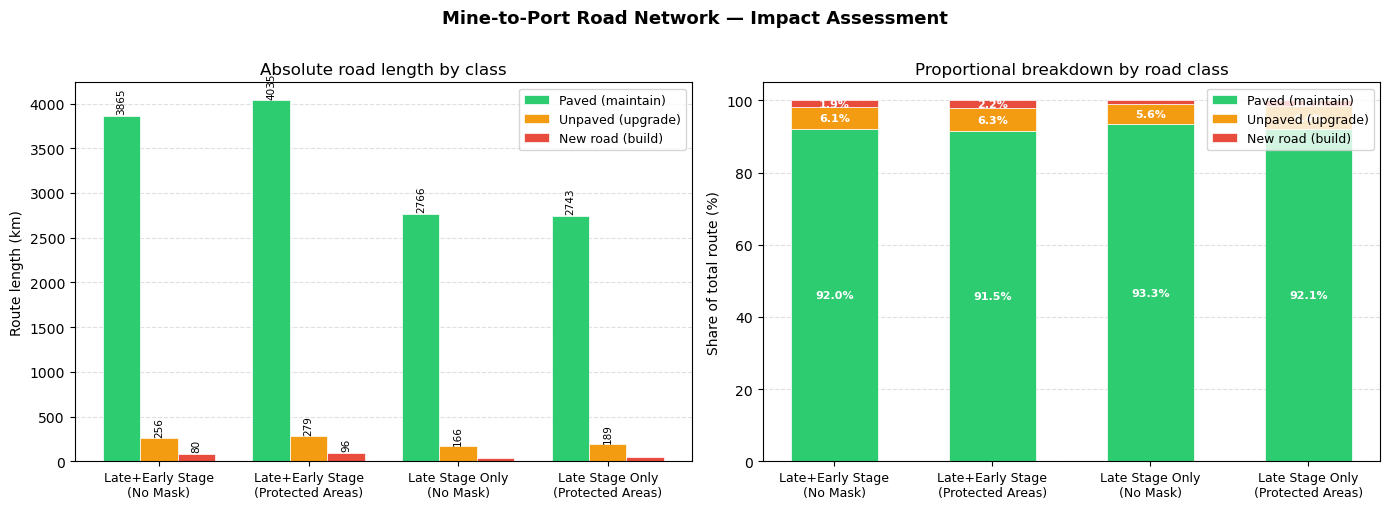

In [16]:
# Colour scheme
COLORS = {
    "paved_km":       "#2ecc71",   # green  — existing paved
    "unpaved_km":     "#f39c12",   # orange — existing unpaved
    "to_be_built_km": "#e74c3c",   # red    — new construction
}
LABELS = {
    "paved_km":       "Paved (maintain)",
    "unpaved_km":     "Unpaved (upgrade)",
    "to_be_built_km": "New road (build)",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mine-to-Port Road Network — Impact Assessment", fontsize=13, fontweight="bold", y=1.01)

scenarios = df_raw["label"].tolist()
x = np.arange(len(scenarios))
categories = ["paved_km", "unpaved_km", "to_be_built_km"]

# ── Left: Absolute km ────────────────────────────────────────────────────────
ax = axes[0]
bar_w = 0.25
offsets = np.array([-1, 0, 1]) * bar_w

for offset, cat in zip(offsets, categories):
    bars = ax.bar(x + offset, df_raw[cat], bar_w,
                  label=LABELS[cat], color=COLORS[cat], edgecolor="white", linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        if h > 50:
            ax.text(bar.get_x() + bar.get_width()/2, h + 20, f"{h:.0f}",
                    ha="center", va="bottom", fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel("Route length (km)")
ax.set_title("Absolute road length by class")
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# ── Right: Proportional stacked bar ──────────────────────────────────────────
ax = axes[1]
bottoms = np.zeros(len(df_raw))
totals  = df_raw["total_km"].values

for cat in categories:
    pcts = df_raw[cat].values / totals * 100
    bars = ax.bar(x, pcts, 0.55, bottom=bottoms,
                  label=LABELS[cat], color=COLORS[cat], edgecolor="white", linewidth=0.5)
    for i, (bar, pct) in enumerate(zip(bars, pcts)):
        if pct > 1.5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottoms[i] + pct/2,
                    f"{pct:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottoms += pcts

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel("Share of total route (%)")
ax.set_title("Proportional breakdown by road class")
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc="upper right")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_scenario_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

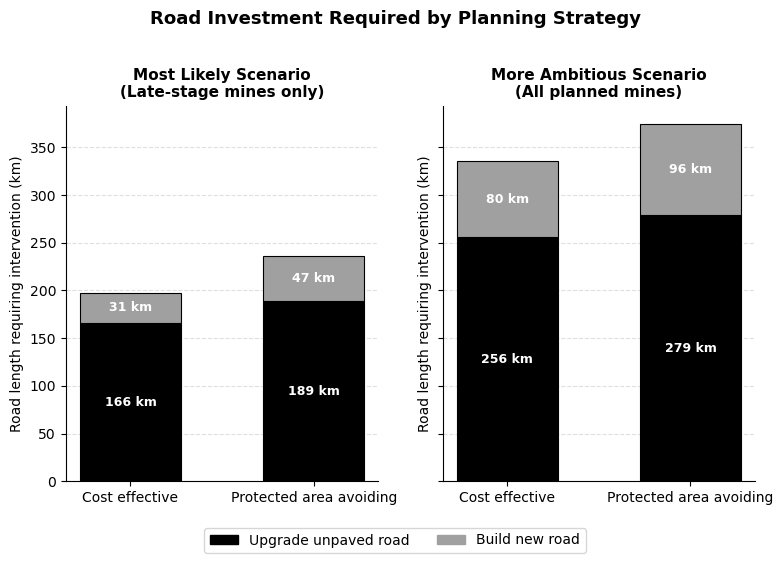

In [17]:
# ── Road investment required: 2 mining scenarios × 2 planning strategies ──────
#
# Each subplot = one mining scenario (how many mines are active)
# Each bar     = one road planning strategy (spatial constraint)
# Bar stack    = unpaved roads to upgrade (orange) + new roads to build (red)

STRATEGY_ORDER  = ["No Mask", "Protected Areas"]
STRATEGY_LABELS = ["Cost effective", "Protected area avoiding"]

INVEST_COLORS = {
    "unpaved_km":     "#000000",   # orange — upgrade existing unpaved
    "to_be_built_km": "#a0a0a0",   # red    — build new road
}
INVEST_LABELS = {
    "unpaved_km":     "Upgrade unpaved road",
    "to_be_built_km": "Build new road",
}

mining_scenarios = [
    {
        "stage":    "Late Stage Only",
        "title":    "Most Likely Scenario",
        "subtitle": "Late-stage mines only",
    },
    {
        "stage":    "Late + Early Stage",
        "title":    "More Ambitious Scenario",
        "subtitle": "All planned mines",
    },
]

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
fig.suptitle(
    "Road Investment Required by Planning Strategy",
    fontsize=13, fontweight="bold", y=1.02
)

x_pos = np.arange(len(STRATEGY_ORDER))
bar_w = 0.55

for ax, scenario in zip(axes, mining_scenarios):
    stage = scenario["stage"]
    rows  = {
        mt: df_raw.loc[
            (df_raw["mining_stage"] == stage) & (df_raw["mask_type"] == mt)
        ].iloc[0]
        for mt in STRATEGY_ORDER
    }

    bottoms = np.zeros(len(STRATEGY_ORDER))
    for cat in ["unpaved_km", "to_be_built_km"]:
        vals = np.array([rows[mt][cat] for mt in STRATEGY_ORDER])
        bars = ax.bar(
            x_pos, vals, bar_w, bottom=bottoms,
            label=INVEST_LABELS[cat],
            color=INVEST_COLORS[cat],
            edgecolor="black", linewidth=0.8
        )
        # Label inside each segment if tall enough
        for bar, v, bot in zip(bars, vals, bottoms):
            if v > 4:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bot + v / 2,
                    f"{v:.0f} km",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold", color="white"
                )
        bottoms += vals

    # # Total label on top of each bar
    # for i, mt in enumerate(STRATEGY_ORDER):
    #     total_inv = rows[mt]["unpaved_km"] + rows[mt]["to_be_built_km"]
    #     ax.text(
    #         x_pos[i], bottoms[i] + 2,
    #         f"{total_inv:.0f} km total",
    #         ha="center", va="bottom", fontsize=9, color="#333333"
    #     )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(STRATEGY_LABELS, fontsize=10)
    ax.set_title(
        f"{scenario['title']}\n({scenario['subtitle']})",
        fontsize=11, fontweight="bold"
    )
    ax.set_ylabel("Road length requiring intervention (km)")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shared legend
handles = [
    mpatches.Patch(color=INVEST_COLORS["unpaved_km"],     label=INVEST_LABELS["unpaved_km"]),
    mpatches.Patch(color=INVEST_COLORS["to_be_built_km"], label=INVEST_LABELS["to_be_built_km"]),
]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.08), frameon=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_investment_by_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# # ── Total least-cost path cost per mine, by scenario and planning strategy ────
# #
# # total_cost = cumulative friction-weighted distance from MCP solver.
# # A higher score means a more difficult / costly corridor to build.
# # Each bar segment represents one mine; colour is consistent across panels.

# # Map scenario key → (mining_stage, mask_type)
# SCEN_META = {k: parse_scenario(k) for k in SCENARIO_PATHS}

# # Collect all mine IDs that have a valid (non-skipped, finite) path
# all_mine_ids = sorted({
#     row["mine_id"]
#     for gdf in SCENARIO_PATHS.values()
#     for _, row in gdf.iterrows()
#     if not row["skipped"] and np.isfinite(row["total_cost"])
# })
# mine_cmap   = plt.get_cmap("tab20", len(all_mine_ids))
# mine_colors = {mid: mine_cmap(i) for i, mid in enumerate(all_mine_ids)}

# mining_scenarios = [
#     {"stage": "Late Stage Only",    "title": "Most Likely Scenario",   "subtitle": "Late-stage mines only"},
#     {"stage": "Late + Early Stage", "title": "More Ambitious Scenario", "subtitle": "All planned mines"},
# ]

# fig, axes = plt.subplots(1, 2, figsize=(13, 15), sharey=True)
# fig.suptitle(
#     "Total Path Cost by Mine and Planning Strategy\n"
#     "(higher = more difficult / costly corridor to build)",
#     fontsize=13, fontweight="bold", y=1.02
# )

# x_pos = np.arange(len(STRATEGY_ORDER))
# bar_w = 0.55

# for ax, scenario in zip(axes, mining_scenarios):
#     stage = scenario["stage"]

#     # Gather valid rows per strategy for this mining stage
#     strategy_gdfs = {}
#     for scen_key, gdf in SCENARIO_PATHS.items():
#         scen_stage, scen_mask = SCEN_META[scen_key]
#         if scen_stage == stage:
#             valid = gdf[~gdf["skipped"] & np.isfinite(gdf["total_cost"])]
#             strategy_gdfs[scen_mask] = valid.set_index("mine_id")["total_cost"]

#     bottoms = np.zeros(len(STRATEGY_ORDER))

#     for mine_id in all_mine_ids:
#         seg_heights = np.array([
#             strategy_gdfs[mt].get(mine_id, 0.0)
#             if mt in strategy_gdfs else 0.0
#             for mt in STRATEGY_ORDER
#         ])
#         if seg_heights.sum() == 0:
#             continue

#         bars = ax.bar(
#             x_pos, seg_heights / 1e6, bar_w,
#             bottom=bottoms / 1e6,
#             color=mine_colors[mine_id],
#             edgecolor="white", linewidth=0.5,
#         )
#         # Mine ID label inside the segment if tall enough
#         for bar, h, bot in zip(bars, seg_heights, bottoms):
#             if h / 1e6 > 0.15:
#                 ax.text(
#                     bar.get_x() + bar.get_width() / 2,
#                     (bot + h / 2) / 1e6,
#                     mine_id.replace("cmr_", ""),
#                     ha="center", va="center",
#                     fontsize=7, color="white", fontweight="bold"
#                 )
#         bottoms += seg_heights

#     # Total label on top
#     for i in range(len(STRATEGY_ORDER)):
#         ax.text(
#             x_pos[i], bottoms[i] / 1e6 + 0.05,
#             f"{bottoms[i]/1e6:.1f}",
#             ha="center", va="bottom", fontsize=9, color="#333333"
#         )

#     ax.set_xticks(x_pos)
#     ax.set_xticklabels(STRATEGY_LABELS, fontsize=10)
#     ax.set_title(
#         f"{scenario['title']}\n({scenario['subtitle']})",
#         fontsize=11, fontweight="bold"
#     )
#     ax.set_ylabel("Cumulative path cost (× 10⁶)")
#     ax.yaxis.grid(True, linestyle="--", alpha=0.4)
#     ax.set_axisbelow(True)
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

# # Legend: one entry per mine
# legend_handles = [
#     mpatches.Patch(color=mine_colors[mid], label=mid)
#     for mid in all_mine_ids
# ]
# fig.legend(
#     handles=legend_handles,
#     loc="lower center", ncol=min(len(all_mine_ids), 7),
#     fontsize=8.5, bbox_to_anchor=(0.5, -0.1),
#     frameon=True, title="Mine ID"
# )

# plt.tight_layout()
# plt.savefig(RESULTS_DIR / "fig_total_cost_by_strategy.png", dpi=150, bbox_inches="tight")
# plt.show()

## Spatial visualization

The classified rasters show which parts of the mine-to-port network
follow existing paved roads (green), unpaved roads (orange), or require
new construction (red).

In [19]:
# Load context layers
cmr_boundary = gpd.read_file(
    DATA_DIR / "input/cmr_admin_boundaries_humdata/cmr_admin0.shp"
)
mines = gpd.read_file(
    DATA_DIR / "output/cmr-mine-locations/all_mines_with_id.gpkg"
)
kribi_port = gpd.read_file(
    DATA_DIR / "input/cmr_ports/kribi-port.shp"
)

# Load existing road network (paved / unpaved)
print("Loading road network …")
roads = gpd.read_file(
    DATA_DIR / "output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg",
    columns=["liu_surface", "geometry"]
)
roads_paved   = roads[roads["liu_surface"] == "paved"]
roads_unpaved = roads[roads["liu_surface"] == "unpaved"]
print(f"  Paved:   {len(roads_paved):,} segments")
print(f"  Unpaved: {len(roads_unpaved):,} segments")

# Load generated path GeoPackages for the 4 scenarios
print("\nLoading generated paths …")
SCENARIO_PATHS = {
    "late_stage__kribi__base__no_mask__ds1":
        gpd.read_file(PATHS_DIR / "late_stage__kribi__base__no_mask__ds1.gpkg"),
    "late_stage__kribi__base__protected_areas__ds1":
        gpd.read_file(PATHS_DIR / "late_stage__kribi__base__protected_areas__ds1.gpkg"),
    "late_and_early_stage__kribi__base__no_mask__ds1":
        gpd.read_file(PATHS_DIR / "late_and_early_stage__kribi__base__no_mask__ds1.gpkg"),
    "late_and_early_stage__kribi__base__protected_areas__ds1":
        gpd.read_file(PATHS_DIR / "late_and_early_stage__kribi__base__protected_areas__ds1.gpkg"),
}
for k, v in SCENARIO_PATHS.items():
    print(f"  {k}: {len(v)} path(s)")

Loading road network …
  Paved:   21,919 segments
  Unpaved: 270,152 segments

Loading generated paths …
  late_stage__kribi__base__no_mask__ds1: 11 path(s)
  late_stage__kribi__base__protected_areas__ds1: 11 path(s)
  late_and_early_stage__kribi__base__no_mask__ds1: 28 path(s)
  late_and_early_stage__kribi__base__protected_areas__ds1: 28 path(s)


In [9]:
# # Styling constants
# ROAD_STYLE = {
#     "paved":   dict(color="#777777", linewidth=0.5, zorder=2, label="Existing paved road"),
#     "unpaved": dict(color="#c8a96e", linewidth=0.5, zorder=2, label="Existing unpaved road"),
# }
# PATH_STYLE = dict(color="#c0392b", linewidth=2.5, alpha=0.65, zorder=4, label="Generated mine-to-port path")

# def plot_scenario_map(ax, scenario_key, title, metrics_row):
#     """
#     Draw one scenario panel:
#       - Cameroon boundary (light fill)
#       - Existing paved + unpaved roads
#       - Generated mine-to-port paths (bold, semi-transparent)
#       - Mine locations and Kribi Port
#       - Metrics annotation box
#     """
#     # Boundary fill
#     cmr_boundary.plot(ax=ax, facecolor="#f5f0e8", edgecolor="#555555", linewidth=1.0, zorder=1)

#     # Existing roads
#     roads_unpaved.plot(ax=ax, **ROAD_STYLE["unpaved"])
#     roads_paved.plot(ax=ax,   **ROAD_STYLE["paved"])

#     # Generated paths
#     paths_gdf = SCENARIO_PATHS[scenario_key]
#     paths_gdf.plot(ax=ax, **PATH_STYLE)

#     # Mines and port
#     mines.plot(ax=ax, color="#1a1a2e", markersize=22, marker="^", zorder=5)
#     kribi_port.plot(ax=ax, color="#0a3d62", markersize=80, marker="*", zorder=6)

#     # Metrics annotation
#     r = metrics_row
#     ann = (
#         f"Total:    {r['total_km']:.0f} km\n"
#         f"Paved:    {r['paved_km']:.0f} km  ({r['paved_km']/r['total_km']*100:.0f}%)\n"
#         f"Upgrade:  {r['unpaved_km']:.0f} km  ({r['unpaved_km']/r['total_km']*100:.0f}%)\n"
#         f"New build:{r['to_be_built_km']:.0f} km  ({r['to_be_built_km']/r['total_km']*100:.0f}%)"
#     )
#     ax.text(
#         0.02, 0.03, ann, transform=ax.transAxes, fontsize=8,
#         verticalalignment="bottom", fontfamily="monospace",
#         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="#aaaaaa")
#     )

#     ax.set_title(title, fontsize=11, fontweight="bold")
#     ax.set_xlabel("Longitude", fontsize=9)
#     ax.set_ylabel("Latitude", fontsize=9)

#     # Clip view to Cameroon extent with a small margin
#     bounds = cmr_boundary.total_bounds  # [minx, miny, maxx, maxy]
#     pad = 0.3
#     ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
#     ax.set_ylim(bounds[1] - pad, bounds[3] + pad)


# # Legend handles (shared across maps)
# MAP_LEGEND = [
#     mpatches.Patch(color="#777777", label="Existing paved road"),
#     mpatches.Patch(color="#c8a96e", label="Existing unpaved road"),
#     mpatches.Patch(color=PATH_STYLE["color"], alpha=PATH_STYLE["alpha"], label="Generated mine-to-port path"),
#     plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#1a1a2e", markersize=9,  label="Mine"),
#     plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="#0a3d62", markersize=13, label="Kribi Port"),
# ]

# print("Map helper ready.")

In [10]:
# # 2×2 overview: all 4 scenarios
# scenario_panels = [
#     ("late_stage__kribi__base__no_mask__ds1",                   "Most Likely — No Restriction"),
#     ("late_stage__kribi__base__protected_areas__ds1",            "Most Likely — Avoid Protected Areas"),
#     ("late_and_early_stage__kribi__base__no_mask__ds1",          "More Ambitious — No Restriction"),
#     ("late_and_early_stage__kribi__base__protected_areas__ds1",  "More Ambitious — Avoid Protected Areas"),
# ]

# fig, axes = plt.subplots(2, 2, figsize=(15, 18))
# fig.suptitle(
#     "Mine-to-Port Road Network — Generated Paths vs Existing Roads\n(Cameroon, Kribi Port)",
#     fontsize=14, fontweight="bold", y=1.01
# )

# for ax, (scen_key, title) in zip(axes.flat, scenario_panels):
#     metrics_row = df_raw[df_raw["scenario"] == scen_key].iloc[0]
#     plot_scenario_map(ax, scen_key, title, metrics_row)

# fig.legend(
#     handles=MAP_LEGEND, loc="lower center", ncol=5,
#     fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=True
# )

# plt.tight_layout()
# plt.savefig(RESULTS_DIR / "fig_paths_overview.png", dpi=150, bbox_inches="tight")
# plt.show()

In [11]:
# # Side-by-side: effect of the Protected Areas constraint
# # (More Ambitious scenario — all planned mines)
# fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# fig.suptitle(
#     "Effect of Protected Areas Constraint on Route Planning\n"
#     "More Ambitious Scenario — All Planned Mines, Kribi Port",
#     fontsize=13, fontweight="bold"
# )

# compare = [
#     ("late_and_early_stage__kribi__base__no_mask__ds1",         "No Restriction"),
#     ("late_and_early_stage__kribi__base__protected_areas__ds1", "Avoid Protected Areas"),
# ]

# for ax, (scen_key, title) in zip(axes, compare):
#     metrics_row = df_raw[df_raw["scenario"] == scen_key].iloc[0]
#     plot_scenario_map(ax, scen_key, title, metrics_row)

# fig.legend(
#     handles=MAP_LEGEND, loc="lower center", ncol=5,
#     fontsize=10, bbox_to_anchor=(0.5, -0.04), frameon=True
# )

# plt.tight_layout()
# plt.savefig(RESULTS_DIR / "fig_paths_constraint_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()

## Key findings

A quick summary extracted directly from the data:

In [12]:
for _, row in df_raw.iterrows():
    total    = row["total_km"]
    paved_p  = row["paved_km"]       / total * 100
    unpav_p  = row["unpaved_km"]     / total * 100
    new_p    = row["to_be_built_km"] / total * 100
    print(
        f"{row['mining_stage']:25s} | {row['mask_type']:20s} | "
        f"Total {total:6.0f} km  | "
        f"Paved {paved_p:4.1f}%  Unpaved {unpav_p:4.1f}%  New {new_p:4.1f}%"
    )

print()
# Delta: extra new road needed due to protected areas constraint
for stage in ["Late Stage Only", "Late + Early Stage"]:
    no_mask_new = df_raw.loc[
        (df_raw["mining_stage"] == stage) & (df_raw["mask_type"] == "No Mask"),
        "to_be_built_km"
    ].values[0]
    pa_new = df_raw.loc[
        (df_raw["mining_stage"] == stage) & (df_raw["mask_type"] == "Protected Areas"),
        "to_be_built_km"
    ].values[0]
    delta = pa_new - no_mask_new
    print(
        f"[{stage}] Protected Areas constraint adds "
        f"{delta:+.1f} km of new construction ({delta/no_mask_new*100:+.1f}%)"
    )

Late + Early Stage        | No Mask              | Total   4201 km  | Paved 92.0%  Unpaved  6.1%  New  1.9%
Late + Early Stage        | Protected Areas      | Total   4410 km  | Paved 91.5%  Unpaved  6.3%  New  2.2%
Late Stage Only           | No Mask              | Total   2963 km  | Paved 93.3%  Unpaved  5.6%  New  1.0%
Late Stage Only           | Protected Areas      | Total   2979 km  | Paved 92.1%  Unpaved  6.4%  New  1.6%

[Late Stage Only] Protected Areas constraint adds +15.9 km of new construction (+51.2%)
[Late + Early Stage] Protected Areas constraint adds +16.3 km of new construction (+20.5%)
